# Phase 3 — Dataset sanity check

Instantiates `EmoMVVideoDataset` for train (stochastic sampling) and val (deterministic sampling) and visually verifies shape, value range, and sampling behavior before trusting it for feature extraction.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> project/ -> repo root
sys.path.insert(0, str(REPO_ROOT))

from project.config import load_config, resolve_path

cfg = load_config()


In [2]:
import torch
import matplotlib.pyplot as plt
from project.datasets.video_dataset import EmoMVVideoDataset

train_ds = EmoMVVideoDataset(resolve_path(cfg, 'paths.train_csv'), mode='train',
                              num_frames=cfg['dataset']['num_frames'],
                              resize_shorter_edge=cfg['dataset']['resize_shorter_edge'],
                              crop_size=cfg['dataset']['crop_size'],
                              log_path=resolve_path(cfg, 'paths.logs_dir') / 'dataset_errors.log')
val_ds = EmoMVVideoDataset(resolve_path(cfg, 'paths.val_csv'), mode='val',
                            num_frames=cfg['dataset']['num_frames'],
                            resize_shorter_edge=cfg['dataset']['resize_shorter_edge'],
                            crop_size=cfg['dataset']['crop_size'])
print('train:', len(train_ds), ' val:', len(val_ds))

train: 2232  val: 479


In [3]:
clip, label, video_id = val_ds[0]
print('shape:', clip.shape, clip.dtype, 'range:', (clip.min().item(), clip.max().item()))
print('label:', label, 'video_id:', video_id)

clip_a, _, _ = val_ds[0]
clip_b, _, _ = val_ds[0]
print('val deterministic across reads:', torch.equal(clip_a, clip_b))

clip_c, _, _ = train_ds[0]
clip_d, _, _ = train_ds[0]
print('train differs across reads:', not torch.equal(clip_c, clip_d))

shape: torch.Size([16, 3, 224, 224]) torch.float32 range: (0.0, 1.0)
label: 0 video_id: DS1__exciting_Exciting_MV_NC07
val deterministic across reads: True
train differs across reads: True


### Visualize sampled frames

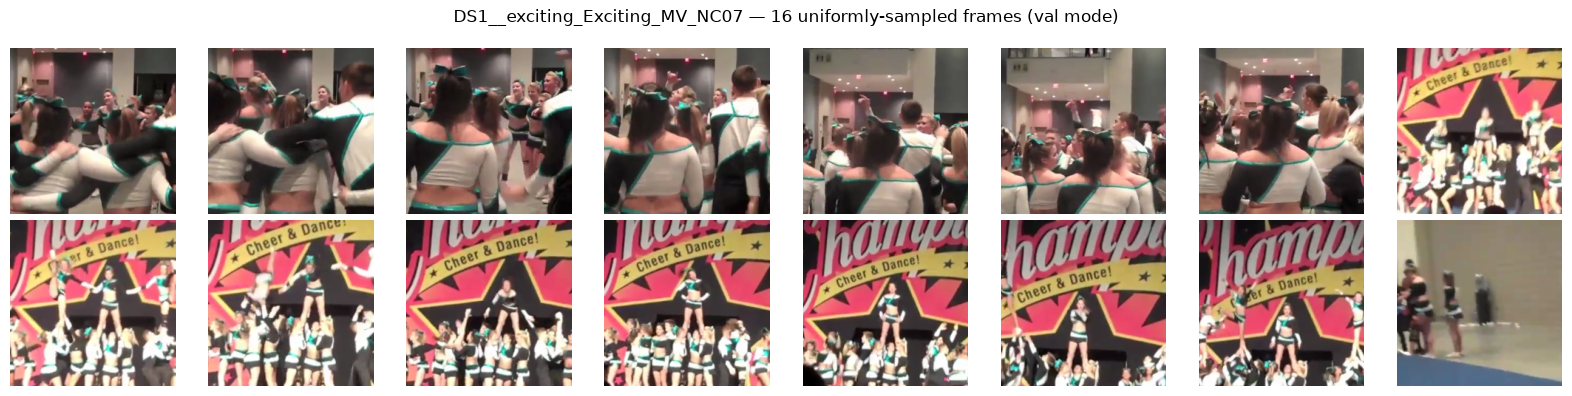

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(clip[i].permute(1, 2, 0).numpy())
    ax.axis('off')
fig.suptitle(f'{video_id} — {cfg["dataset"]["num_frames"]} uniformly-sampled frames (val mode)')
plt.tight_layout(); plt.show()